# Hotel Booking Cancellation Prediction

**Overview**

This project builds machine learning models to predict hotel booking cancellations using reservation and guest data.  
The objective is to help hotels proactively identify high-risk bookings and reduce revenue loss.

**Approach**
- Exploratory Data Analysis (EDA) to understand booking behavior
- Feature encoding for categorical variables
- Tree-based classification models:
  - ##### Decision Tree
  - ##### Random Forest
- Hyperparameter tuning using GridSearchCV and RandomizedSearchCV
- Evaluation using Accuracy, Recall, F1-Score, and AUC

**Key Findings**
- Default decision trees severely overfit the training data
- Random Forest models significantly improve generalization
- Tuned Random Forest achieved the strongest test-set performance (F1 ≈ 0.85)
- Results demonstrate practical value for early cancellation risk detection


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
# split the data into train and test
from sklearn.model_selection import train_test_split
df = pd.read_csv("Hotel_reservation.csv")

# To build a Random forest classifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# To tune a model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.metrics import (
    recall_score,
    accuracy_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    make_scorer,
    roc_curve
)

FileNotFoundError: [Errno 2] No such file or directory: 'Hotel_reservation.csv'

In [27]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [28]:
df.info()
#df.isnull().sum() - checks for missing values in each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [29]:
#how many unique values exist in each column
df.nunique()

Booking_ID                              36275
no_of_adults                                5
no_of_children                              6
no_of_weekend_nights                        8
no_of_week_nights                          18
type_of_meal_plan                           4
required_car_parking_space                  2
room_type_reserved                          7
lead_time                                 352
arrival_year                                2
arrival_month                              12
arrival_date                               31
market_segment_type                         5
repeated_guest                              2
no_of_previous_cancellations                9
no_of_previous_bookings_not_canceled       59
avg_price_per_room                       3930
no_of_special_requests                      6
booking_status                              2
dtype: int64

In [30]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [31]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
# +1:positive linearcorrelationi(as 1 variable increase,the other increase proportionally)
# -1: negative linear correlation
# 0: no linear correlation
df[numeric_columns].corr()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
no_of_adults,1.000000,-0.019787,0.103316,0.105622,0.011429,0.097287,0.076719,0.021841,0.026338,-0.192277,-0.047426,-0.119166,0.296886,0.189401
no_of_children,-0.019787,1.000000,0.029478,0.024398,0.034244,-0.047091,0.045983,-0.003076,0.025482,-0.036348,-0.016390,-0.021189,0.337728,0.124486
no_of_weekend_nights,0.103316,0.029478,1.000000,0.179577,-0.031111,0.046595,0.055357,-0.009894,0.027304,-0.067107,-0.020690,-0.026312,-0.004525,0.060593
no_of_week_nights,0.105622,0.024398,0.179577,1.000000,-0.048784,0.149650,0.032672,0.037376,-0.009305,-0.099764,-0.030080,-0.049344,0.022753,0.045994
required_car_parking_space,0.011429,0.034244,-0.031111,-0.048784,1.000000,-0.066445,0.015684,-0.015505,-0.000037,0.110909,0.027106,0.063810,0.061304,0.087922
lead_time,0.097287,-0.047091,0.046595,0.149650,-0.066445,1.000000,0.143439,0.136814,0.006479,-0.135984,-0.045723,-0.078137,-0.062596,-0.101645
arrival_year,0.076719,0.045983,0.055357,0.032672,0.015684,0.143439,1.000000,-0.339689,0.018849,-0.018175,0.003919,0.026422,0.178605,0.053205
arrival_month,0.021841,-0.003076,-0.009894,0.037376,-0.015505,0.136814,-0.339689,1.000000,-0.042780,0.000341,-0.038615,-0.010718,0.054423,0.110552
arrival_date,0.026338,0.025482,0.027304,-0.009305,-0.000037,0.006479,0.018849,-0.042780,1.000000,-0.015949,-0.012542,-0.001498,0.017898,0.018352
repeated_guest,-0.192277,-0.036348,-0.067107,-0.099764,0.110909,-0.135984,-0.018175,0.000341,-0.015949,1.000000,0.390810,0.539156,-0.174900,-0.011820


<Axes: >

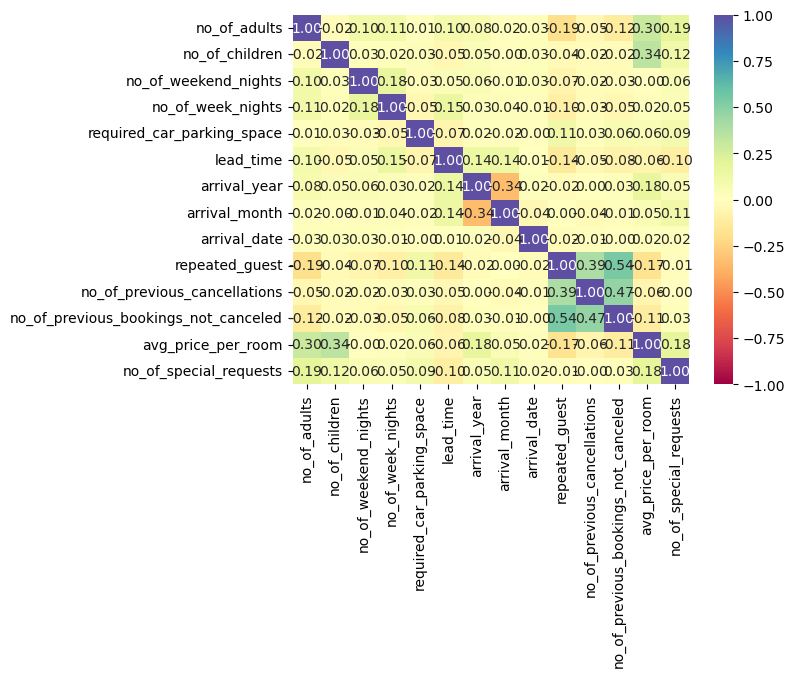

In [32]:
sns.heatmap(df[numeric_columns].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")

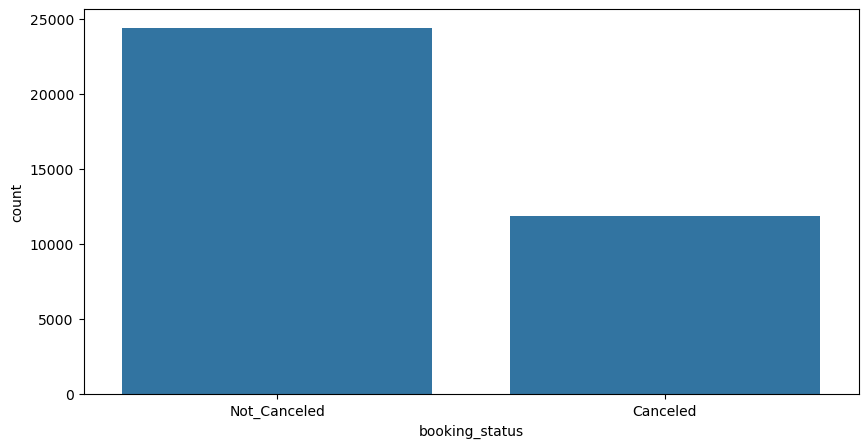

In [33]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="booking_status")
plt.show()

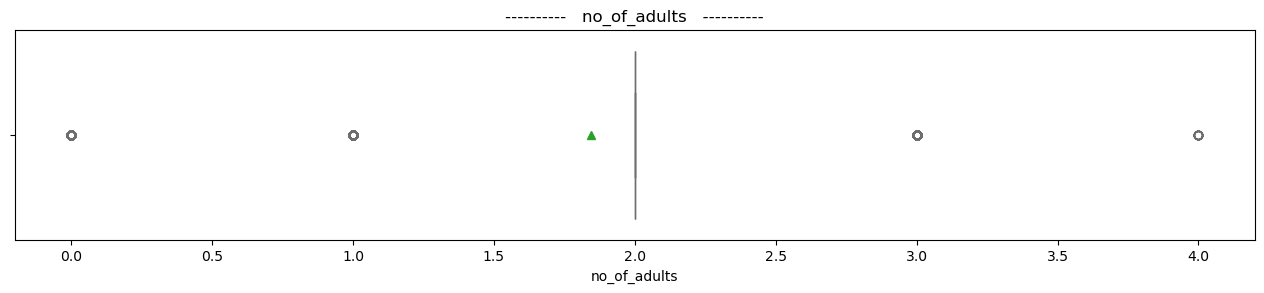

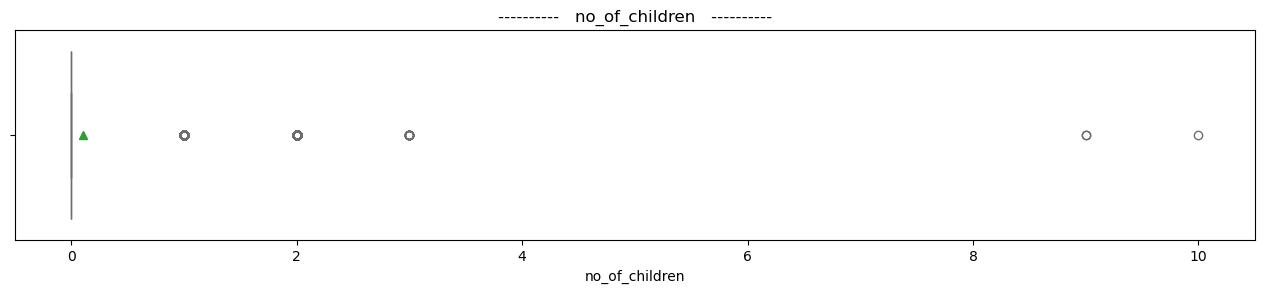

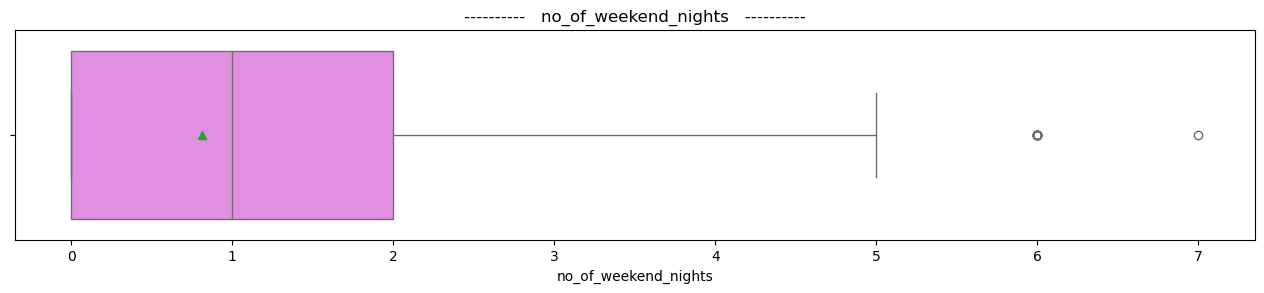

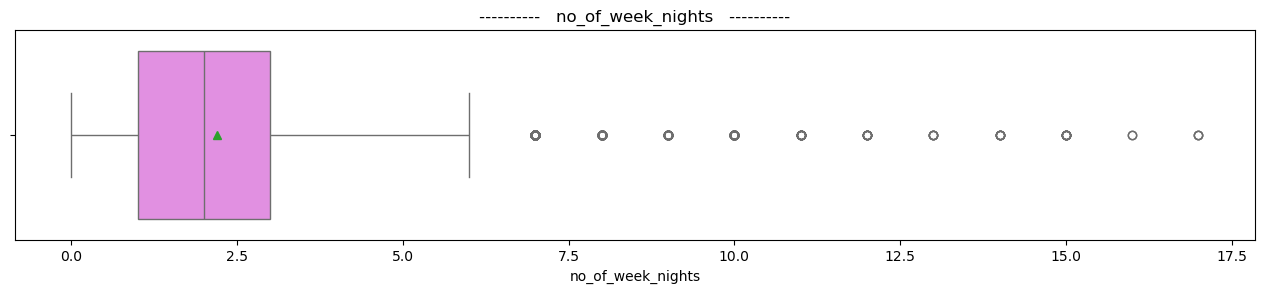

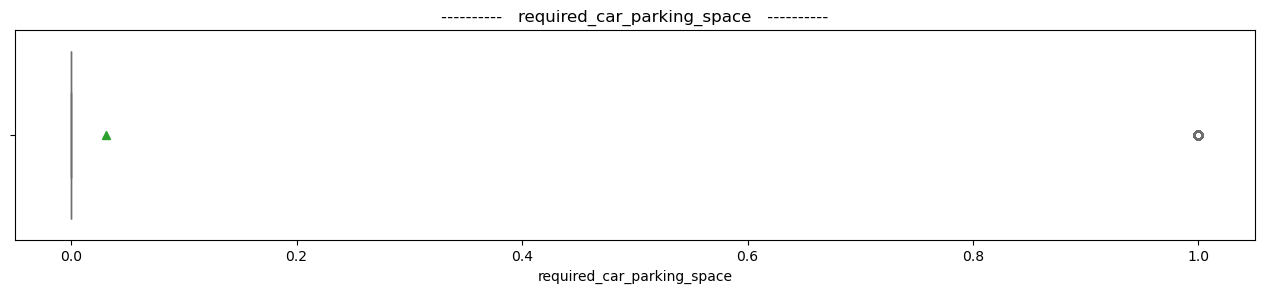

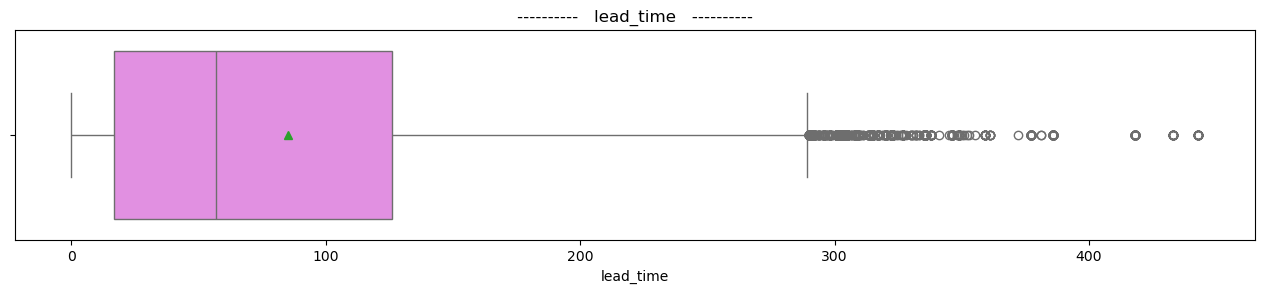

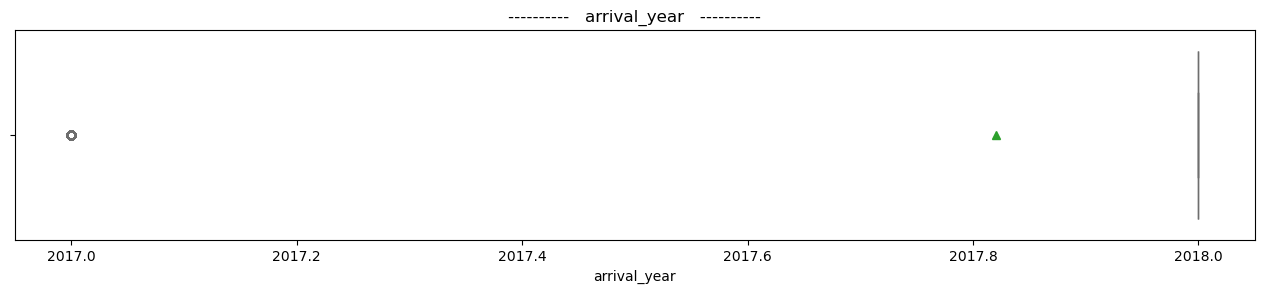

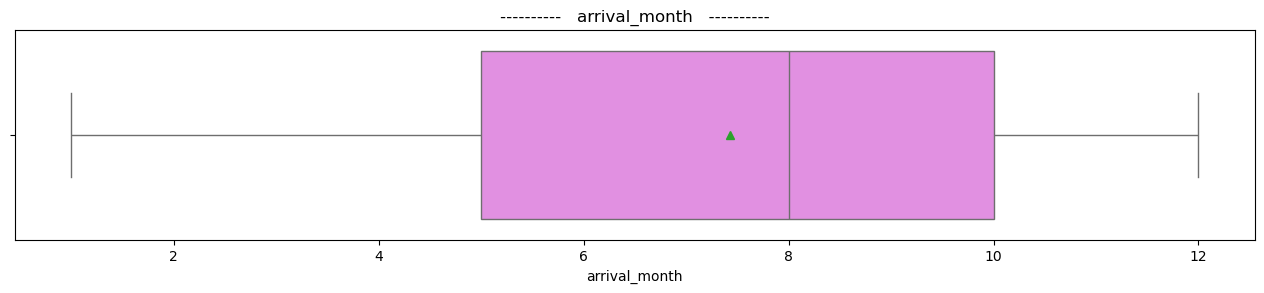

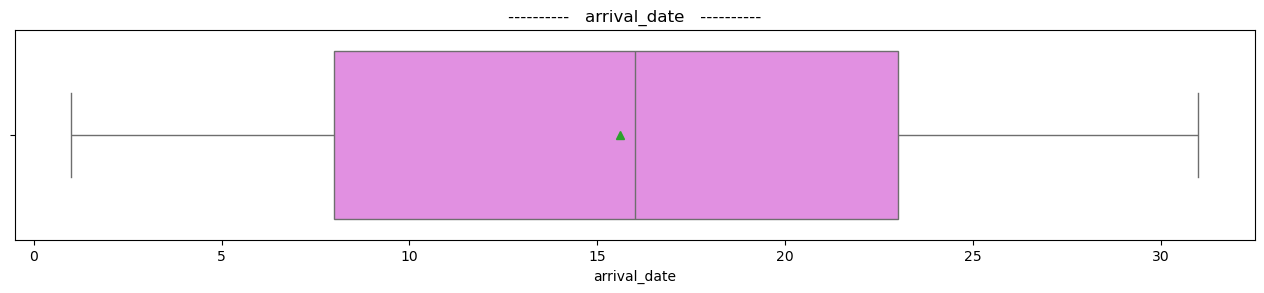

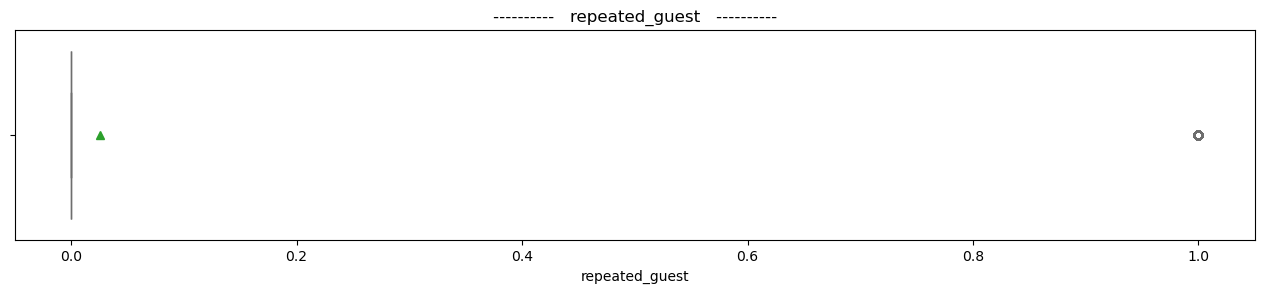

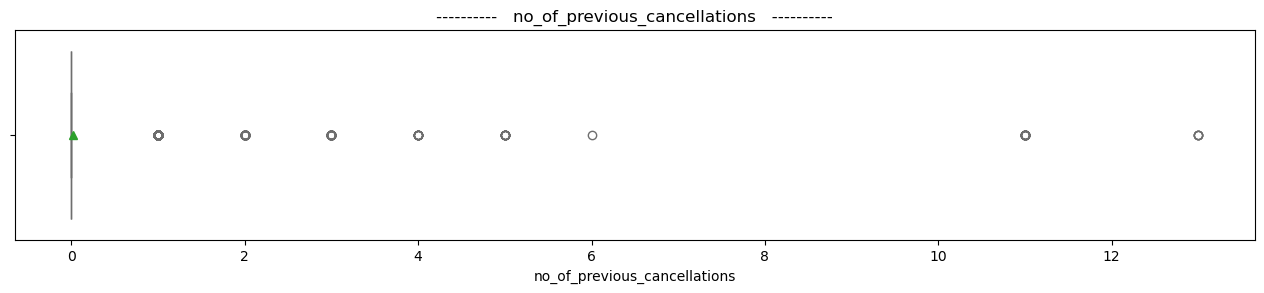

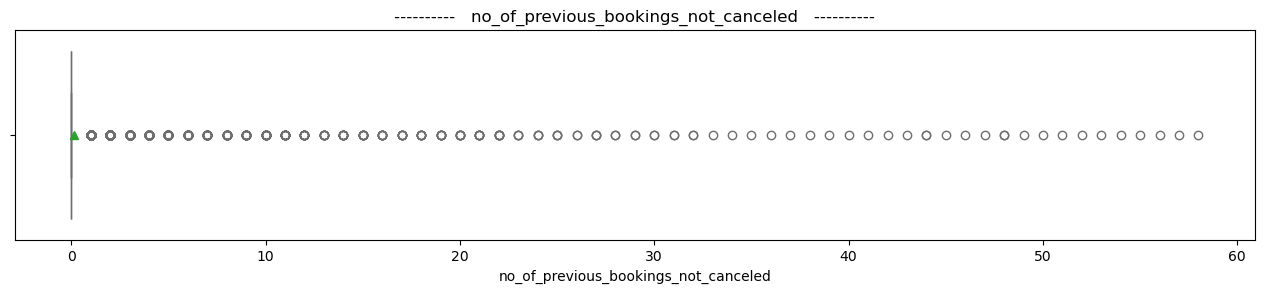

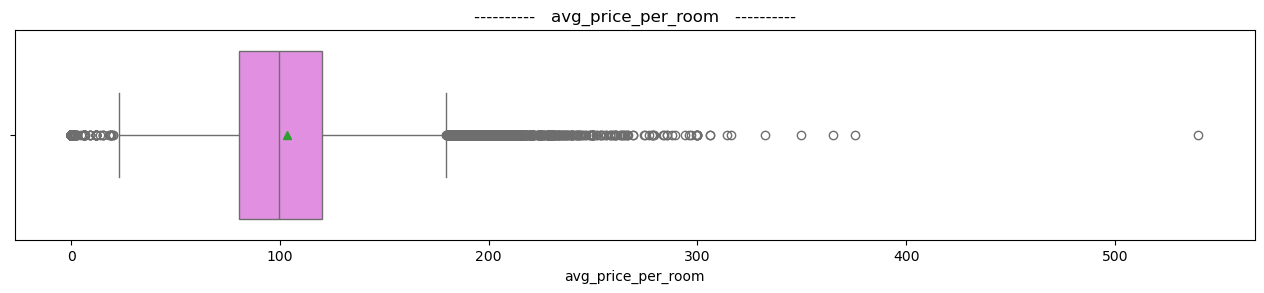

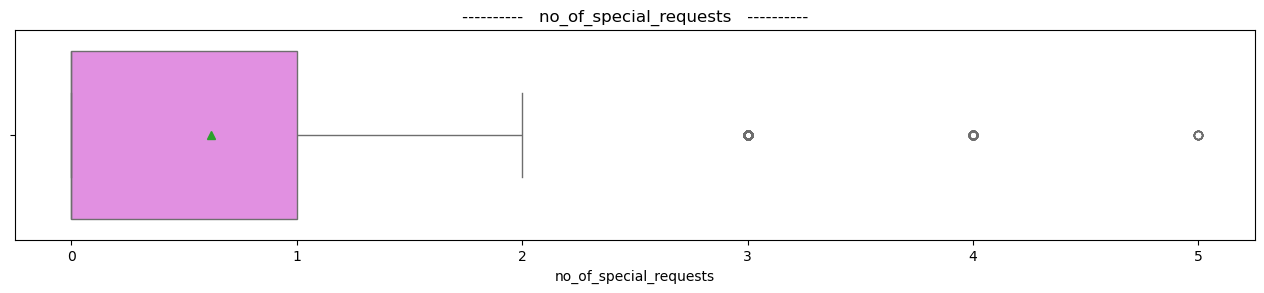

In [34]:
for col in numeric_columns:
    plt.figure(figsize=(16, 6))
    plt.subplot(2, 1, 1)
    plt.title("----------   " + col + "   ----------")
    sns.boxplot(data=df, x=col, showmeans=True, color="violet")
    

Observation: The dataset contains 36,275 records and no missing values across its 19 features. The target variable booking_status is imbalanced, with significantly more bookings labeled as Not_Canceled than Canceled, meaning most reservations were fulfilled. The correlation heatmap shows very weak relationships among numerical variables, indicating that no single numeric feature strongly explains cancellation on its own.

In [35]:
#checks for missing values in each column
df.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [36]:
# 1 = canceled (positive class), 0 = Not canceled.
df["booking_status"] = df["booking_status"].apply(lambda x: 1 if x == "Canceled" else 0)

In [37]:
# Drop booking ID, so the drop_first=True arguement can be removed from get_dummies 
#since Decision tree and random forest require one-hot encoding and it doesn't accept string categories
df = df.drop("Booking_ID", axis=1)

In [38]:
df['booking_status'].value_counts(normalize=True)

booking_status
0    0.672364
1    0.327636
Name: proportion, dtype: float64

In [39]:
#one-hot encoding, handles categorical data 
categorical_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

# removed -, drop_first=True because not doing linear or logistic regression, tree base model do not suffer from multicollinearity
df= pd.get_dummies(df, columns=categorical_cols)

In [40]:
#define what X and Y is for the split data later. Y is the Target
X = df.drop('booking_status', axis=1)
y= df['booking_status']

In [41]:
# Check if stratify should be true
df["booking_status"].value_counts(normalize=True)

booking_status
0    0.672364
1    0.327636
Name: proportion, dtype: float64

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

X = all features except the target
Y = only the target column

In [43]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 29020
Number of rows in test data = 7255


In [44]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,2017,10,2,0,...,False,False,False,False,False,False,False,False,True,False
1,2,0,2,3,0,5,2018,11,6,0,...,False,False,False,False,False,False,False,False,False,True
2,1,0,2,1,0,1,2018,2,28,0,...,False,False,False,False,False,False,False,False,False,True
3,2,0,0,2,0,211,2018,5,20,0,...,False,False,False,False,False,False,False,False,False,True
4,2,0,1,1,0,48,2018,4,11,0,...,False,False,False,False,False,False,False,False,False,True


In [45]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

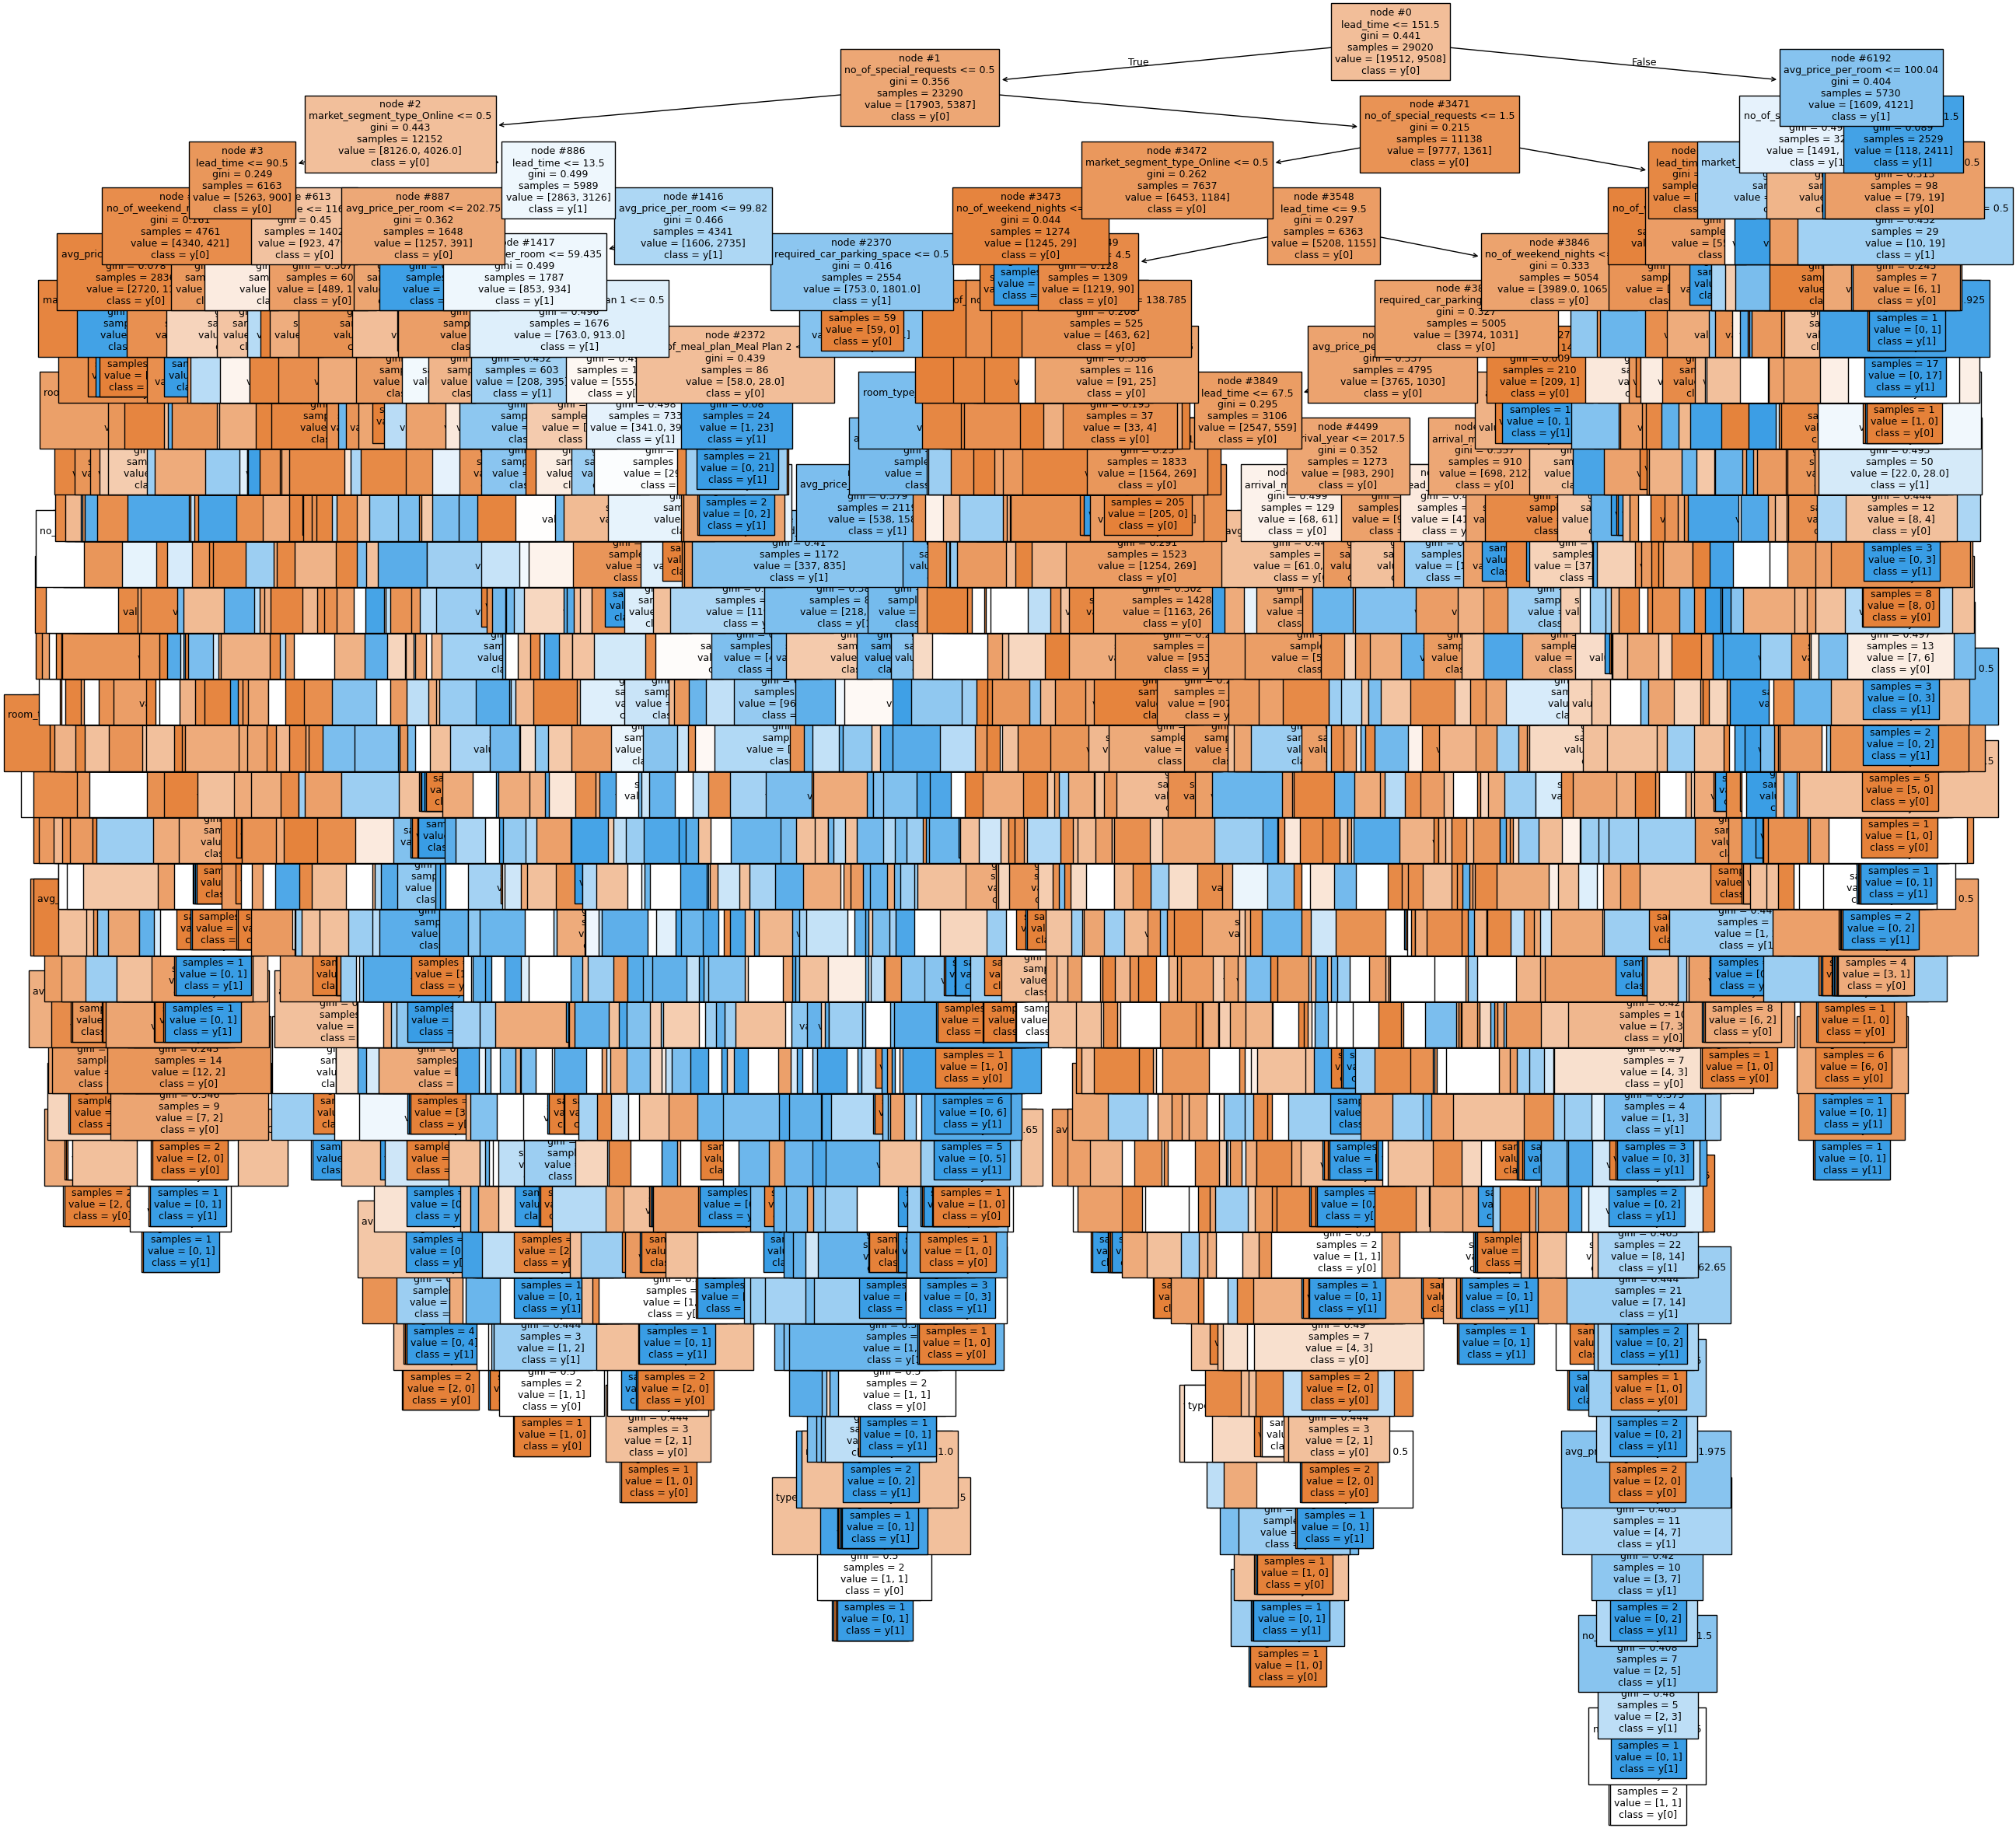

In [46]:
plt.figure(figsize=(30, 30))
plot_tree(dt, feature_names=X_train.columns.to_list(), filled=True, fontsize=9, node_ids=True, class_names=True)
plt.show()

In [47]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_sklearn(model, predictors, target, threshold=0.5):
    pred = model.predict_proba(predictors)[:,1] > threshold

    acc = accuracy_score(target, pred)  
    b_acc = balanced_accuracy_score(target, pred) # balanced accuracy: average of recall obtained on each class
    recall = recall_score(target, pred)  
    precision = precision_score(target, pred)  
    f1 = f1_score(target, pred)  
    auc = roc_auc_score(target, model.predict_proba(predictors)[:,1])

    df_perf = pd.DataFrame({"Accuracy": acc, "Balanced Accuracy": b_acc,
                            "Recall": recall, "Precision": precision,
                            "F1": f1, "AUC": auc}, index=[0],)
    return df_perf

In [48]:
print("performance on Decision Tree training data")
dt_train_perf = model_performance_classification_sklearn(dt, X_train, y_train, threshold=0.5)
display(dt_train_perf)

print("performance on Decision Tree test data")
dt_test_perf = model_performance_classification_sklearn(dt, X_test, y_test, threshold=0.5)
display(dt_test_perf)

performance on Decision Tree training data


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.994142,0.992139,0.986327,0.995753,0.991018,0.999891


performance on Decision Tree test data


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.874156,0.856267,0.804375,0.810169,0.807262,0.858494


Observation: The default decision tree is clearly overfitting the training data. The training accuracy is extremely high at 0.994, but it drops to 0.874 on the test set. Similarly, F1 score falls from 0.991 (train) to 0.807 (test), and AUC decreases from 0.999 to 0.858. as a result, the model does not generalize well and is overfit.

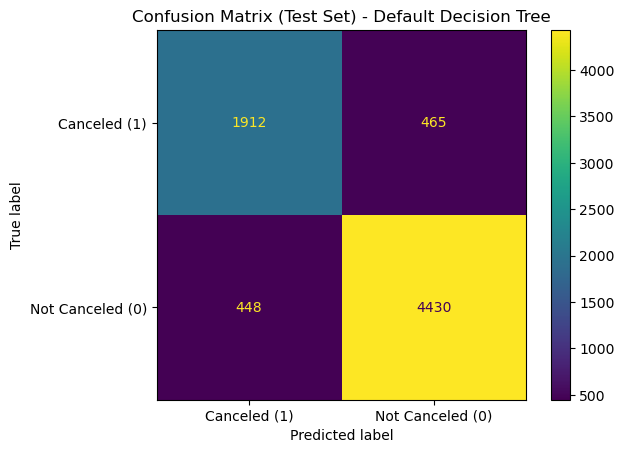

In [49]:
# the Function goal:
# Confusion matrix - shows how well your classification model predicted the classes. 
# compares what the model predicted vs what the true labels really were
# answers one question:
# 👉 Where is my model getting things right, and where is it making mistakes?

# predict using the default decision tree
y_pred_test = dt.predict(X_test)

# build confusion matrix with 'Canceled' as positive class
cm = confusion_matrix(y_test, y_pred_test, labels=[1, 0])

# display
disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Canceled (1)', 'Not Canceled (0)']
)
disp.plot()
plt.title("Confusion Matrix (Test Set) - Default Decision Tree")
plt.show()

AUC Score (Test Set): 0.858


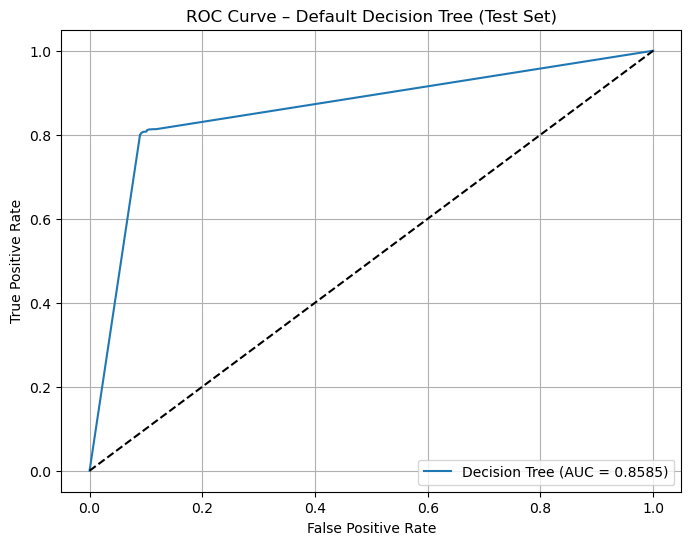

In [50]:
# 1. Get predicted probabilities for the positive class (Canceled = 1) this happenend above with the lambda function on booking_status
# in all sklearn: positive class = 1
#so [:,1] means probability of class 1 probability of canceled thus canceled = positive class                                   
                #predict_proba(X_test) returns [p(class 0), p(class 1)]
                                        # but [:,1] = select all rows(:) and the second column (1)
                                        #so only returns: p(class 1),
y_test_prob = dt.predict_proba(X_test)[:,1]

# 2. Compute FPR, TPR for ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

# 3. Compute AUC
auc_score = roc_auc_score(y_test, y_test_prob)
print("AUC Score (Test Set): {:.3f}".format(auc_score))

# 4. Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label="Decision Tree (AUC = {:.4f})".format(auc_score))
plt.plot([0,1], [0,1], "k--")  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Default Decision Tree (Test Set)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [51]:

parameters = {
    "max_depth": [3, 5, 7, 9],
    "min_samples_split": [5, 10, 20, 50],
    "max_leaf_nodes": [10, 25, 50, 100],
    "min_samples_leaf": [5, 10, 15, 20],
    "max_features": ['sqrt', 'log2', None],
}

f1_scorer = make_scorer(f1_score)

# Grid search with 5-fold CV
grid_obj_dt = GridSearchCV(dt, parameters,
                           scoring=f1_scorer,
                           cv=5,
                           n_jobs=-1,
                           verbose=2)

# Fit on training data
grid_obj_dt = grid_obj_dt.fit(X_train, y_train)
grid_obj_dt.best_params_
# best_params_ is an attribute of GridSearchCV AFTER it finishes searching
#(returns a dictionary (key–value pairs))

Fitting 5 folds for each of 768 candidates, totalling 3840 fits


{'max_depth': 9,
 'max_features': None,
 'max_leaf_nodes': 100,
 'min_samples_leaf': 5,
 'min_samples_split': 5}

In [52]:

best_params = grid_obj_dt.best_params_                      #“Go into the dictionary best_params, retrieve the value stored under the key 'max_depth'.”
dt_best = DecisionTreeClassifier(                              #dictionary indexing
    max_depth = best_params['max_depth'],                      #so looks like this: 'max_depth': 9, (9 is the best hyperparameter found)
    min_samples_split = best_params['min_samples_split'],      # 'min_samples_split': 5,         (5 is the best hyperparameter found) 
    min_samples_leaf = best_params['min_samples_leaf'],       
    max_features = best_params['max_features'],
    max_leaf_nodes = best_params['max_leaf_nodes'],
    random_state = 42
)

dt_best.fit(X_train, y_train)


dt_best_train_perf = model_performance_classification_sklearn(
    dt_best, X_train, y_train, threshold=0.5)

dt_best_test_perf = model_performance_classification_sklearn(
    dt_best, X_test, y_test, threshold=0.5)

print("performance on new decision tree with the optimal hyperparameter training data")
display(dt_best_train_perf)
print("performance on new decision tree with the optimal hyperparameter testing data")
display(dt_best_test_perf)

performance on new decision tree with the optimal hyperparameter training data


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.870951,0.842506,0.759992,0.831626,0.794197,0.927742


performance on new decision tree with the optimal hyperparameter testing data


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.87581,0.849732,0.774085,0.834846,0.803318,0.929326


In [53]:
dt_random = DecisionTreeClassifier(random_state=42)

rand_params = {
    "max_depth": np.arange(3, 10),
    "min_samples_split": [5, 10, 20, 30, 50],
    "min_samples_leaf": [5, 10, 15, 20],
    "max_features": ['sqrt', 'log2', None]
}

rand_obj_dt = RandomizedSearchCV(
    estimator = dt_random,
    param_distributions = rand_params,
    n_iter = 20,
    scoring = f1_scorer,
    cv = 5,
    n_jobs = -1,
    random_state = 42,
    verbose = 2
)

rand_obj_dt.fit(X_train, y_train)


rand_best_params = rand_obj_dt.best_params_
rand_best_params


Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'min_samples_split': 20,
 'min_samples_leaf': 15,
 'max_features': None,
 'max_depth': np.int64(9)}

In [54]:
rand_best_params = rand_obj_dt.best_params_

# Create a NEW decision tree with those tuned hyperparameters
dt_rand_best = DecisionTreeClassifier(
    max_depth = rand_best_params['max_depth'],
    min_samples_split = rand_best_params['min_samples_split'],
    min_samples_leaf = rand_best_params['min_samples_leaf'],
    max_features = rand_best_params['max_features'],
    random_state = 42
)

# Fit on training data
dt_rand_best.fit(X_train, y_train)

dt_rand_train_perf = model_performance_classification_sklearn(
    dt_rand_best, X_train, y_train, threshold=0.5
)
dt_rand_test_perf = model_performance_classification_sklearn(
    dt_rand_best, X_test, y_test, threshold=0.5
)

print("performance on new decision tree with tuned hyperparameters training data")
display(dt_rand_train_perf)
print("performance on new decision tree with tuned hyperparameters training data")
display(dt_rand_test_perf)



performance on new decision tree with tuned hyperparameters training data


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.870606,0.844488,0.768721,0.824478,0.795624,0.934078


performance on new decision tree with tuned hyperparameters training data


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.873053,0.848329,0.776609,0.825581,0.800347,0.92997


In [55]:
# model without hyperparameter tuning
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [56]:
print('Evaluation metrics of RandomForest on the training dataset')
rf_train_perf =  model_performance_classification_sklearn(rf, X_train, y_train, threshold=0.5)
display(rf_train_perf)

print('Evaluation metrics of RandomForest on the testing dataset')
rf_test_perf = model_performance_classification_sklearn(rf, X_test, y_test, threshold=0.5)
display(rf_test_perf)


Evaluation metrics of RandomForest on the training dataset


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.994142,0.99257,0.98801,0.994074,0.991033,0.999393


Evaluation metrics of RandomForest on the testing dataset


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.906961,0.883682,0.816155,0.890725,0.851811,0.957134


The default random forest performs extremely well on the training set (Accuracy ≈ 0.99, F1 ≈ 0.99), 
which indicates a very strong fit to the training data. However, the test performance drops to around 0.90 accuracy and 0.85 F1, 
showing a clear gap between training and testing results. This gap indicates that the model is overfitting, 
although it still generalizes reasonably well compared to a single decision tree.

In [23]:
# Grid of parameters to choose from
rf_params = {
     "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

f1_scorer = make_scorer(f1_score)

rand_obj_rf = GridSearchCV(
        rf, 
        rf_params, 
        scoring=f1_scorer,
        cv=5,
        n_jobs=1,
        verbose=2,
)

rand_obj_rf.fit(X_train, y_train)

rf_best_params =rand_obj_rf.best_params_
rf_best_params


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.4s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.4s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total ti

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [57]:
rf2_tuned = RandomForestClassifier(
    n_estimators = rf_best_params['n_estimators'],
    min_samples_leaf = rf_best_params['min_samples_leaf'],
    max_features = rf_best_params['max_features'],
    max_depth = rf_best_params['max_depth'],
    random_state=42)

rf2_tuned.fit(X_train, y_train)


# model performance on the training dataset
print('Evaluation metrics of random forest with optimal hyperparameter on the training dataset')
rf2_tuned_train_perf = model_performance_classification_sklearn(rf2_tuned, X_train, y_train, threshold=0.5)
display(rf2_tuned_train_perf)

# model performance on the testing dataset
print('Evaluation metrics of random forest with optimal hyperparameter on the testing dataset')
rf2_tuned_test_perf = model_performance_classification_sklearn(rf2_tuned, X_test, y_test, threshold=0.5)
display(rf2_tuned_test_perf)

Evaluation metrics of random forest with optimal hyperparameter on the training dataset


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.994142,0.99257,0.98801,0.994074,0.991033,0.999393


Evaluation metrics of random forest with optimal hyperparameter on the testing dataset


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.906961,0.883682,0.816155,0.890725,0.851811,0.957134


In [65]:
print("Model	                                        F1 Score (Test)")
print("Default Decision Tree	                        0.807")
print("Tuned Decision Tree – GridSearchCV	        0.803")
print("Tuned Decision Tree – RandomizedSearchCV	  0.800")
print("Default Random Forest	                        0.851")
print("Tuned Random Forest - GridSearchCV	         0.851")

Model	                                        F1 Score (Test)
Default Decision Tree	                        0.807
Tuned Decision Tree – GridSearchCV	        0.803
Tuned Decision Tree – RandomizedSearchCV	  0.800
Default Random Forest	                        0.851
Tuned Random Forest - GridSearchCV	         0.851



Based on the F1 score metric, the Random Forest model is the most appropriate choice.
Both the default and tuned Random Forest models achieve the highest F1 score on the test set (≈0.851), outperforming all variations of the Decision Tree.

The Decision Tree models show lower F1 scores and noticeable overfitting, while the Random Forest generalizes better and provides the best balance between precision and recall. Therefore, the Random Forest model is selected as the best-performing classifier for this task.


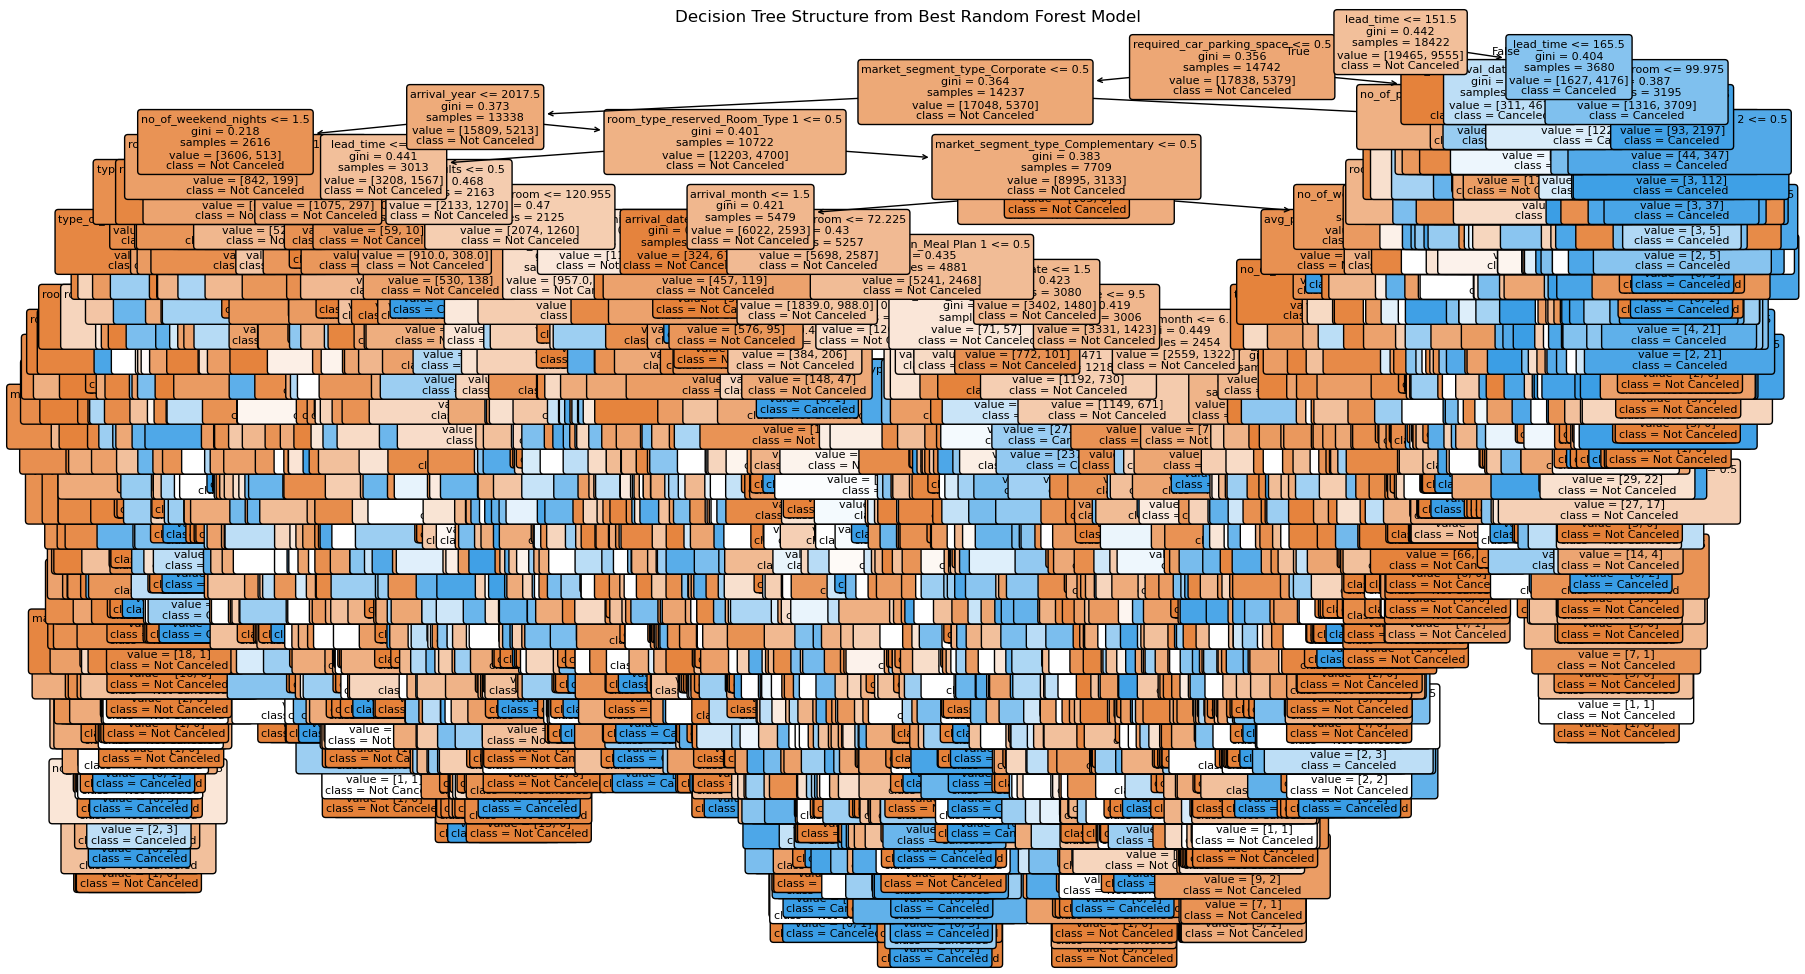

In [25]:
one_tree = rf2_tuned.estimators_[0] 

plt.figure(figsize=(20, 12))
tree.plot_tree(
    one_tree,
    feature_names=X_train.columns,
    class_names=['Not Canceled', 'Canceled'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Structure from Best Random Forest Model")
plt.show()
